# <center> **Практика**
## <center> **ML-7. Прогнозирование биологического ответа (HW-3)**

Наша практика будет основана на соревновании [Kaggle: Predicting a Biological Response](https://www.kaggle.com/c/bioresponse) (Прогнозирование биологического ответа).

>Необходимо предсказать биологический ответ молекул (**столбец 'Activity'**) по их химическому составу (столбцы D1-D1776).

Импортируем необходимые библиотеки

In [1]:
#импорт библиотек
import numpy as np #для матричных вычислений
import pandas as pd #для анализа и предобработки данных
import matplotlib.pyplot as plt #для визуализации
import seaborn as sns #для визуализации

from sklearn import linear_model #линейные моделиё
from sklearn import tree #деревья решений
from sklearn import ensemble #ансамбли
from sklearn import metrics #метрики
from sklearn import preprocessing #предобработка
from sklearn.model_selection import train_test_split #сплитование выборки

%matplotlib inline
plt.style.use('seaborn-v0_8')

Читаем данные, смотрим на размеры датасета и тип данных

In [2]:
data = pd.read_csv('../data_ml7/data.csv')
data.head()

,Activity,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,D1767,D1768,D1769,D1770,D1771,D1772,D1773,D1774,D1775,D1776
0,1,0.000000,0.497009,0.10,0.0,0.132956,0.678031,0.273166,0.585445,0.743663,...,0,0,0,0,0,0,0,0,0,0
1,1,0.366667,0.606291,0.05,0.0,0.111209,0.803455,0.106105,0.411754,0.836582,...,1,1,1,1,0,1,0,0,1,0
2,1,0.033300,0.480124,0.00,0.0,0.209791,0.610350,0.356453,0.517720,0.679051,...,0,0,0,0,0,0,0,0,0,0
3,1,0.000000,0.538825,0.00,0.5,0.196344,0.724230,0.235606,0.288764,0.805110,...,0,0,0,0,0,0,0,0,0,0
4,0,0.100000,0.517794,0.00,0.0,0.494734,0.781422,0.154361,0.303809,0.812646,...,0,0,0,0,0,0,0,0,0,0


In [3]:
data.dtypes.value_counts()

float64    942
int64      835
Name: count, dtype: int64

In [4]:
data.shape

(3751, 1777)

Каждая строка представляет молекулу. 
* Первый столбец ```Activity``` содержит экспериментальные данные, описывающие фактический биологический ответ [0, 1]; 
* Остальные столбцы ```D1-D1776``` представляют собой молекулярные **дескрипторы** — это вычисляемые свойства, которые могут фиксировать некоторые характеристики молекулы, например размер, форму или состав элементов.


>Предварительная обработка не требуется, данные уже закодированы и нормализованы.

В качестве метрики будем использовать ```F1-score```.

Необходимо обучить две модели: **логистическую регрессию** и **случайный лес**. Далее нужно сделать подбор гиперпараметров с помощью **базовых** и **продвинутых методов оптимизации**. Важно использовать все четыре метода (```GridSeachCV, RandomizedSearchCV, Hyperopt, Optuna```) хотя бы по разу, **максимальное количество итераций не должно превышать 50**.

---

Смотрим на сбалансированность классов:

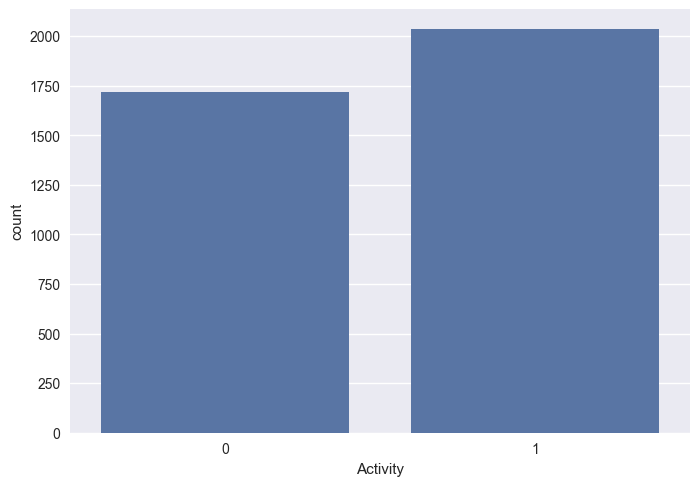

In [5]:
sns.countplot(data=data, x='Activity');

In [6]:
data['Activity'].value_counts(normalize=True)

Activity
1    0.542255
0    0.457745
Name: proportion, dtype: float64

>ВЫВОД: 
* Распределение 0.54/0.46 считают условно сбалансированным. 
* Сильного дисбаланса тут нет: разница всего в 8 процентных пунктов, ни один класс не является «редким». 
* Стратифицированное разбиение всё равно лучше использовать.
* Стратификация гарантирует, что пропорции классов в train и test будут близки к исходным — и оценка модели будет надёжнее.
* Отдельные методы борьбы с дисбалансом (SMOTE, undersampling, oversampling) не нужны


---

Создаем матрицу наблюдений $X$ и вектор ответов $y$

In [7]:
X = data.drop(['Activity'], axis=1)
y = data['Activity']

Разделяем выборку на тренировочную и тестовую в соотношении 80/20. Для сохранения соотношений целевого признака используем параметр stratify (стратифицированное разбиение). 

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 1, test_size = 0.2)

---

#### **Логистическая регрессия**

Зафиксируем метрику, которая была получена без дополнительной настройки, т.е со значениями гиперпараметров, установленных по умолчанию:

In [54]:
#Создаем объект класса логистическая регрессия
log_reg = linear_model.LogisticRegression(max_iter = 1000)
#Обучаем модель, минимизируя logloss
log_reg.fit(X_train, y_train)
y_test_pred = log_reg.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

f1_score на тестовом наборе: 0.78


>ВЫВОД №1:
Со значениями геперпараметров по умолчанию в модели логистической регрессии получена метрика $F_1$ - 0.78

#### **Случайный лес**

Зафиксируем метрику, которая была получена без дополнительной настройки, т.е со значениями гиперпараметров, установленных по умолчанию:

In [21]:
#Создаем объект класса случайный лес
rf = ensemble.RandomForestClassifier(random_state=42)
#Обучаем модель
rf.fit(X_train, y_train)
#Выводим значения метрики 
y_train_pred = rf.predict(X_train)
print('Train: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
y_test_pred = rf.predict(X_test)
print('Test: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

Train: 1.00
Test: 0.81


>ВЫВОД №2: со значениями геперпараметров по умолчанию в модели случайный лес получена метрика $F_1$ - 0.81

---

# <center> **Базовые методы оптимизации**

**1. Воспользуемся методом подбора гиперпараметров GridSearchCV**

In [12]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    # lbfgs + l2
    {'penalty': ['l2'], 'solver': ['lbfgs'], 'C': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]},
    # saga + l1, l2, elasticnet
    {'penalty': ['l1', 'l2', 'elasticnet'], 'solver': ['saga'], 'C': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1], 'l1_ratio': [0.1, 0.5, 0.9]},
    # liblinear + l1, l2
    {'penalty': ['l1', 'l2'], 'solver': ['liblinear'], 'C': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1]}
]

grid_search = GridSearchCV(
    estimator=linear_model.LogisticRegression(
        random_state=42,
        max_iter=1000
    ),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    error_score='raise'               
)

%time grid_search.fit(X_train, y_train)

y_test_pred = grid_search.predict(X_test)
print("F1-score на тестовом наборе: {:.2f}".format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search.best_params_))

CPU times: total: 16.9 s
Wall time: 22min 41s
F1-score на тестовом наборе: 0.79
Наилучшие значения гиперпараметров: {'C': 0.1, 'l1_ratio': 0.9, 'penalty': 'elasticnet', 'solver': 'saga'}


>ВЫВОД: при использовании метода GridSearchCV
* в модели логистической регрессии наилучшие значения гиперпараметров: {'C': 0.1, 'l1_ratio': 0.9, 'penalty': 'elasticnet', 'solver': 'saga'}
* получена метрика $F_1$ - 0.79

In [14]:
result_cv = pd.DataFrame(grid_search.cv_results_)
result_cv.head(2)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,param_solver,param_l1_ratio,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.086392,0.288184,0.045811,0.011416,0.01,l2,lbfgs,NaN,"{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}",0.738333,0.763333,0.780,0.745000,0.746667,0.754667,0.015107,28
1,2.455983,0.683600,0.052132,0.012572,0.10,l2,lbfgs,NaN,"{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}",0.730000,0.763333,0.775,0.761667,0.760000,0.758000,0.014959,7


In [15]:
result_cv.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_C', 'param_penalty', 'param_solver', 'param_l1_ratio', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='object')

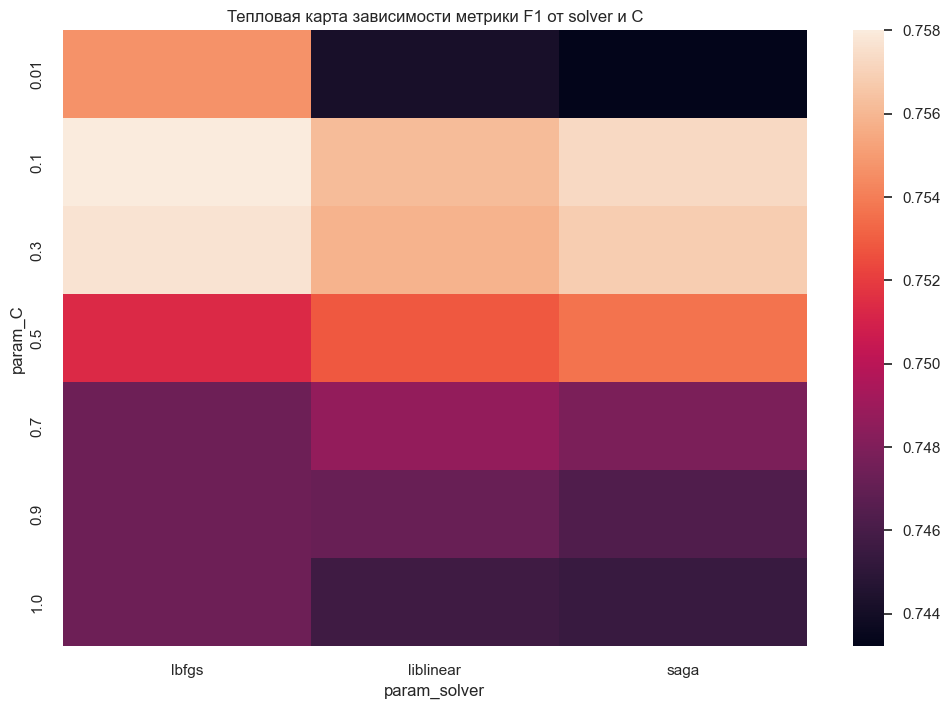

In [17]:
visual = pd.pivot_table(pd.DataFrame(grid_search.cv_results_),
               values='mean_test_score', index='param_C',
               columns='param_solver')
sns.heatmap(visual)
plt.title('Тепловая карта зависимости метрики F1 от solver и С') # подпись графика
sns.set(rc={'figure.figsize':(12, 8)}) #задаем размер графика

Видим, что наилучшие значения метрики достигаются при 'C': 0.1, 'solver': 'saga' и 'lbfgs'

---

**2. Воспользуемся методом подбора гиперпараметров RandomizedSearchCV**

In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {'penalty': ['l2', None] ,
              'solver': ['lbfgs', 'sag'],
               'C': list(np.linspace(0.01, 1, 10, dtype=float))}
            
random_search = RandomizedSearchCV(
    estimator=linear_model.LogisticRegression(random_state=42, max_iter=50), 
    param_distributions=param_distributions, 
    cv=5, 
    n_iter = 10, 
    n_jobs = -1
)  
%time random_search.fit(X_train, y_train) 

y_test_pred = random_search.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(random_search.best_params_))

CPU times: total: 1.89 s
Wall time: 17.5 s
f1_score на тестовом наборе: 0.79
Наилучшие значения гиперпараметров: {'solver': 'sag', 'penalty': 'l2', 'C': 0.56}


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Попробуем изменить сетку параметров

In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {'penalty': ['l1', 'l2', 'elasticnet'], 'solver': ['saga'], 'C': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 1], 'l1_ratio': [0.1, 0.5, 0.9]}
            
random_search = RandomizedSearchCV(
    estimator=linear_model.LogisticRegression(random_state=42, max_iter=50), 
    param_distributions=param_distributions, 
    cv=5, 
    n_iter = 10, 
    n_jobs = -1
)  
%time random_search.fit(X_train, y_train) 

y_test_pred = random_search.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(random_search.best_params_))

CPU times: total: 3.19 s
Wall time: 22.2 s
f1_score на тестовом наборе: 0.79
Наилучшие значения гиперпараметров: {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.9, 'C': 0.3}


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


>ВЫВОД:
В результате использования метода RandomizedSearchCV улучшить метрику не получилось

---

**3. Теперь зададим сетку гиперпараметров для модели случайный лес и подберем оптимальные гиперпараметры методом ```GridSearchCV()``` :**

In [22]:
param_grid = {'n_estimators': list(range(100, 300, 40)),
              'min_samples_leaf': [5],
              'max_depth': list(np.linspace(20, 40, 5, dtype=int))
              }
            
grid_search_forest = GridSearchCV(
    estimator=ensemble.RandomForestClassifier(random_state=42), 
    param_grid=param_grid, 
    cv=5, 
    n_jobs = -1
)  

%time grid_search_forest.fit(X_train, y_train) 

y_train_pred = grid_search_forest.predict(X_train)

print('f1_score на обучающем наборе: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))
y_test_pred = grid_search_forest.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(grid_search_forest.best_params_))

CPU times: total: 4.11 s
Wall time: 48.1 s
f1_score на обучающем наборе: 0.95
f1_score на тестовом наборе: 0.83
Наилучшие значения гиперпараметров: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 220}


>Вывод: используя GridSearchCV получена метрика f1_score на тестовом наборе: 0.83

**4. Воспользуемся методом ```RandomizedSearchCV()``` для модели случайного леса**

In [23]:
param_distributions = {'n_estimators': list(range(50, 500, 40)),
              'min_samples_leaf': [5],
              'max_depth': list(np.linspace(20, 40, 10, dtype=int))
              }
            
random_search_forest = RandomizedSearchCV(
    estimator=ensemble.RandomForestClassifier(random_state=42), 
    param_distributions=param_distributions, 
    cv=5,
    n_iter = 10, 
    n_jobs = -1
)  

%time random_search_forest.fit(X_train, y_train) 

y_train_pred = random_search_forest.predict(X_train)
print('f1_score на обучающем наборе: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))

y_test_pred = random_search_forest.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))
print("Наилучшие значения гиперпараметров: {}".format(random_search_forest.best_params_))

CPU times: total: 5.55 s
Wall time: 18.9 s
f1_score на обучающем наборе: 0.95
f1_score на тестовом наборе: 0.83
Наилучшие значения гиперпараметров: {'n_estimators': 330, 'min_samples_leaf': 5, 'max_depth': 22}


>Вывод: используя метод RandomizedSearchCV для случайного леса улучшить метрику не удалось, но время подбора параметров сократилось более, чем в 2 раза

---

# <center> **Продвинутые методы оптимизации**

**5. Метод hyperopt для логистической регрессии**

In [34]:
from sklearn.model_selection import cross_val_score
import hyperopt
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import StratifiedKFold

Настроим оптимизацию гиперпараметров для алгоритма логистической регрессии.

In [36]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(params):
    C = float(params['C'])
    penalty = params['penalty']
    
    # Для elasticnet всегда нужен l1_ratio; для остальных — нет
    if penalty == 'elasticnet':
        model = linear_model.LogisticRegression(
            penalty=penalty,
            C=C,
            solver='saga',          # только saga поддерживает elasticnet
            l1_ratio=params['l1_ratio'],
            max_iter=50,
            random_state=42,
            n_jobs=-1
        )
    else:
        # l1: liblinear или saga; l2: lbfgs, saga, liblinear и т.д.
        model = linear_model.LogisticRegression(
            penalty=penalty,
            C=C,
            solver=params['solver'],
            max_iter=50,
            random_state=42,
            n_jobs=-1
        )

    score = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1').mean()
    return {'loss': -score, 'status': STATUS_OK}

# Пространство с заранее валидными конфигурациями
space = hp.choice('config', [
    {
        'penalty': 'l1',
        'solver': hp.choice('l1_solver', ['liblinear', 'saga']),
        'C': hp.loguniform('l1_C', np.log(0.01), np.log(10))
    },
    {
        'penalty': 'l2',
        'solver': hp.choice('l2_solver', ['lbfgs', 'saga', 'liblinear']),
        'C': hp.loguniform('l2_C', np.log(0.01), np.log(10))
    },
    {
        'penalty': 'elasticnet',
        'solver': 'saga',  # фиксируем, т.к. только он поддерживает elasticnet
        'C': hp.loguniform('en_C', np.log(0.01), np.log(10)),
        'l1_ratio': hp.uniform('en_l1_ratio', 0.0, 1.0)
    }
])

trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.RandomState(42)
)

print("Лучшие параметры (внутренние индексы):", best)

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site

  2%|▏         | 1/50 [00:01<01:17,  1.58s/trial, best loss: -0.7763699977754468]

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



  4%|▍         | 2/50 [00:11<05:03,  6.32s/trial, best loss: -0.7829036755917066]

...

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_mode

 98%|█████████▊| 49/50 [04:06<00:04,  4.07s/trial, best loss: -0.7871412884918247]

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site

100%|██████████| 50/50 [04:06<00:00,  4.94s/trial, best loss: -0.7871412884918247]
Лучшие параметры (внутренние индексы): {'config': 1, 'l2_C': 0.11880043081613455, 'l2_solver': 2}


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(



In [37]:
from hyperopt import space_eval
best_params = space_eval(space, best)
print("Расшифрованные лучшие параметры:", best_params)

Расшифрованные лучшие параметры: {'C': 0.11880043081613455, 'penalty': 'l2', 'solver': 'liblinear'}


In [40]:
from sklearn.metrics import f1_score

penalty = best_params['penalty']
C = float(best_params['C'])

if penalty == 'elasticnet':
    final_model = linear_model.LogisticRegression(
        penalty=penalty,
        C=C,
        solver='saga',
        l1_ratio=float(best_params['l1_ratio']),
        max_iter=50,
        random_state=42,
        n_jobs=-1
    )
else:
    final_model = linear_model.LogisticRegression(
        penalty=penalty,
        C=C,
        solver=best_params['solver'],
        max_iter=50,
        random_state=42,
        n_jobs=-1
    )

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
f1_test = f1_score(y_test, y_pred)  
print(f"F1 (test): {f1_test:.2f}")

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(


F1 (test): 0.79


>Вывод: С помощью продвинутого метода оптимизации hyperopt метрика F1 равна 0,79

---

**6. Воспользуемся продвинутым методом оптимизации гиперпараметров optuna для логистической регрессии**

In [42]:
def objective(trial):
    # 1. Выбираем сразу валидную комбинацию (penalty, solver)
    # Это обходит ограничение Optuna на динамические пространства
    combo = trial.suggest_categorical(
        'penalty_solver',
        [
            ('l1', 'liblinear'),
            ('l1', 'saga'),
            ('l2', 'lbfgs'),
            ('l2', 'saga'),
            ('l2', 'liblinear'),
            ('elasticnet', 'saga'),  # только saga для elasticnet
        ]
    )
    penalty, solver = combo

    # 2. C в логарифмическом масштабе
    C = trial.suggest_float('C', 1e-4, 1e2, log=True)

    # 3. l1_ratio нужен только для elasticnet; для остальных ставим None
    if penalty == 'elasticnet':
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
    else:
        l1_ratio = None

    model = linear_model.LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        l1_ratio=l1_ratio,
        max_iter=50,
        random_state=42,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scorer = make_scorer(f1_score, average='binary')

    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring=f1_scorer)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Лучший F1 (CV):", study.best_value)
print("Лучшие параметры:", study.best_params)

[I 2026-07-13 00:09:32,337] A new study created in memory with name: no-name-161e7ee3-96bd-4a7c-826a-18ecbb352474


  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('l1', 'liblinear') which is of type tuple.
  optuna_warn(message)
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('l1', 'saga') which is of type tuple.
  optuna_warn(message)
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains ('l2', 'lbfgs') which is of type tuple.
  optuna_warn(message)
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\distributions.

[I 2026-07-13 00:09:41,979] Trial 0 finished with value: 0.7829253979361693 and parameters: {'penalty_solver': ('l1', 'saga'), 'C': 3.8313930105463165}. Best is trial 0 with value: 0.7829253979361693.


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bo

...

[I 2026-07-13 00:14:30,089] Trial 46 finished with value: 0.7784352349565211 and parameters: {'penalty_solver': ('l2', 'saga'), 'C': 0.007798099348909673}. Best is trial 9 with value: 0.7871378063147061.


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not c

[I 2026-07-13 00:14:39,531] Trial 47 finished with value: 0.7834101793999613 and parameters: {'penalty_solver': ('l1', 'saga'), 'C': 2.3231261070785165}. Best is trial 9 with value: 0.7871378063147061.


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 18.
  warnings.warn(
c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-pac

[I 2026-07-13 00:14:40,189] Trial 48 finished with value: 0.7643995780783459 and parameters: {'penalty_solver': ('l2', 'liblinear'), 'C': 0.0024208342342259773}. Best is trial 9 with value: 0.7871378063147061.
[I 2026-07-13 00:14:42,604] Trial 49 finished with value: 0.7844844112523457 and parameters: {'penalty_solver': ('l2', 'lbfgs'), 'C': 0.06722460824418586}. Best is trial 9 with value: 0.7871378063147061.
Лучший F1 (CV): 0.7871378063147061
Лучшие параметры: {'penalty_solver': ('l2', 'lbfgs'), 'C': 0.12678852179509914}


In [43]:
best_params = study.best_params
penalty, solver = best_params['penalty_solver']
C = best_params['C']

if penalty == 'elasticnet':
    l1_ratio = best_params['l1_ratio']
else:
    l1_ratio = None

final_model = linear_model.LogisticRegression(
    penalty=penalty,
    C=C,
    solver=solver,
    l1_ratio=l1_ratio,
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
print("F1 на тесте:", f1_score(y_test, y_pred, average='binary'))

F1 на тесте: 0.7865707434052758


>Вывод: используя метод Optuna финальная метрика получилась так же 0.79

---

**7. Воспользуемся продвинутым методом оптимизации гиперпараметров Hyperopt для алгоритма случайного леса.**

In [44]:
# зададим пространство поиска гиперпараметров
space={'n_estimators': hp.quniform('n_estimators', 100, 200, 1),
       'max_depth' : hp.quniform('max_depth', 15, 26, 1),
       'min_samples_leaf': hp.quniform('min_samples_leaf', 2, 10, 1)
      }

In [46]:
# зафксируем random_state
random_state = 42
def hyperopt_rf(params, cv=5, X=X_train, y=y_train, random_state=random_state):
    # функция получает комбинацию гиперпараметров в "params"
    params = {'n_estimators': int(params['n_estimators']), 
              'max_depth': int(params['max_depth']), 
             'min_samples_leaf': int(params['min_samples_leaf'])
              }
  
    # используем эту комбинацию для построения модели
    model = ensemble.RandomForestClassifier(**params, random_state=random_state)

    # обучаем модель
    model.fit(X, y)
    score = metrics.f1_score(y, model.predict(X))

    # метрику необходимо минимизировать, поэтому ставим знак минус
    return -score

In [47]:
%%time
# начинаем подбор гиперпараметров

trials = Trials() # используется для логирования результатов

best=fmin(hyperopt_rf, # наша функция 
          space=space, # пространство гиперпараметров
          algo=tpe.suggest, # алгоритм оптимизации, установлен по умолчанию, задавать необязательно
          max_evals=20, # максимальное количество итераций
          trials=trials, # логирование результатов
          rstate=np.random.RandomState(random_state)# фиксируем для повторяемости результата
         )
print("Наилучшие значения гиперпараметров {}".format(best))

100%|██████████| 20/20 [00:37<00:00,  1.86s/trial, best loss: -0.991421568627451] 
Наилучшие значения гиперпараметров {'max_depth': 24.0, 'min_samples_leaf': 2.0, 'n_estimators': 153.0}
CPU times: total: 35.7 s
Wall time: 37.2 s


In [48]:
# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(
    random_state=random_state, 
    n_estimators=int(best['n_estimators']),
    max_depth=int(best['max_depth']),
    min_samples_leaf=int(best['min_samples_leaf'])
)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
print('f1_score на обучающем наборе: {:.2f}'.format(metrics.f1_score(y_train, y_train_pred)))

y_test_pred = model.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

f1_score на обучающем наборе: 0.99
f1_score на тестовом наборе: 0.82


>Вывод: используя метод оптимизации Hyperopt для случайного леса достигнуто значение метрики F1 0.82

---

**8. Воспользуемся продвинутым методом оптимизации гиперпараметров Optuna для алгоритма случайного леса.**

In [49]:
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
  max_depth = trial.suggest_int('max_depth', 15, 40, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 7, 1)

  # создаем модель
  model = ensemble.RandomForestClassifier(n_estimators=n_estimators,
                                          max_depth=max_depth,
                                          min_samples_leaf=min_samples_leaf,
                                          random_state=random_state)
  # обучаем модель
  model.fit(X_train, y_train)
  score = metrics.f1_score(y_train, model.predict(X_train))

  return score 
  

In [50]:
%%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо максимизировать метрику direction="maximize"
study = optuna.create_study(study_name="RandomForestClassifier", direction="maximize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study.optimize(optuna_rf, n_trials=20)

[I 2026-07-13 00:24:24,643] A new study created in memory with name: RandomForestClassifier
C:\Users\PC\AppData\Local\Temp\ipykernel_40408\418696813.py:3: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
C:\Users\PC\AppData\Local\Temp\ipykernel_40408\418696813.py:4: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresp

CPU times: total: 54 s
Wall time: 56.1 s


In [51]:
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study.best_params))
print("f1_score на обучающем наборе: {:.2f}".format(study.best_value))

Наилучшие значения гиперпараметров {'n_estimators': 220, 'max_depth': 36, 'min_samples_leaf': 3}
f1_score на обучающем наборе: 0.98


In [52]:
# рассчитаем точность для тестовой выборки
model = ensemble.RandomForestClassifier(**study.best_params,random_state=random_state, )
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)
print('f1_score на тестовом наборе: {:.2f}'.format(metrics.f1_score(y_test, y_test_pred)))

f1_score на тестовом наборе: 0.83


>Вывод: методом оптимизации Optuna на модели случайного леса достигнута наилучшая метрика F1 - 0,83

---

## **ОБЩИЙ ВЫВОД ПО РАБОТЕ:**

1. Для модели логистической регрессии были достигнуты следующая метрика $F_1$ при нижеописанных методах оптимизации геперпараметров:
    * гиперпараметры по умолчанию - F1 = 0.78
    * GridSearchCV - F1 = 0.79
    * RandomizedSearchCV - F1 = 0.79
    * Hyperopt - F1 = 0.79
    * Optuna - F1 = 0.79

2. Для модели случайного леса были достигнуты следующая метрика $F_1$ при нижеописанных методах оптимизации геперпараметров:
    * гиперпараметры по умолчанию - F1 = 0.81
    * GridSearchCV - F1 = 0.83
    * RandomizedSearchCV - F1 = 0.83
    * Hyperopt - F1 = 0.82
    * Optuna - F1 = 0.83

Были освоены методы оптимизации гиперпараметров двух разных моделей бинарной классификации